In [ ]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch import tensor

import numpy as np
import pandas as pd
import networkx as nx

In [ ]:
DATA_ROOT = '/home/alexanderb/LEMBAS-RNN-benchmark'

# Aims outline

Use same as first attempt but replace linear function with MML functon from LEMBAS

### Load datasets

In [ ]:
net = pd.read_csv(f"{DATA_ROOT}/Full data files/network(full).tsv", sep='\t')

In [ ]:
network = nx.from_pandas_edgelist(net, 
                             source='TF', 
                             target='Gene', 
                             edge_attr='Interaction')

In [ ]:
gene_expressions = pd.read_csv((f"{DATA_ROOT}/Full data files/Geneexpression (full).tsv"), sep='\t', header=0)

In [ ]:
TF_expressions = pd.read_csv((f"{DATA_ROOT}/Full data files/TF(full).tsv"), sep='\t', header=0)

In [ ]:
#filter genes to nodes in network
TF_expressions = TF_expressions[[gene for gene in TF_expressions.columns if gene in list(network.nodes)]]
gene_expressions = gene_expressions[[gene for gene in gene_expressions.columns if gene in list(network.nodes)]] 

### Creating dataset object

In [ ]:
#torch tutorial code to use accelerator when available
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [ ]:
from torch.utils.data import Dataset


class CustomTFGE(Dataset):
    def __init__(self, device, TF_expressions, gene_expressions, target_gene, network, transform=None, target_transform=None):
        '''
        Custom dataset for loading expression data across all TFs and samples and one target gene expression across all samples
        For a given index will return all TF expressions in one sample and target gene expression across all samples

        Parameters
        --------------
        device : torch device
            torch device to put dataset on, must be the same device as the model
        TF_expressions : Pandas dataframe
            pandas dataframe of TF expressions where columns are gene names and rows are samples. Expressions should be TPM normalised and log10 transformed.
        gene_expressions : Pandas dataframe
            pandas dataframe of target gene expressions, columns are gene names and rows are samples. Expressions should be TPM normalised and log10 transformed.
        target_gene : String
            String containing name of target gene for given model.
        network : networkx network
            Undirected network of the singalling pathway of interest. Used to filter TFs used when predicting target gene expression.
        '''
        #no transforms needed so set to none
        self.transform = transform
        self.target_transform = target_transform

        #load network
        self.network = network
        self.TF_expressions = TF_expressions
        self.gene_expressions = gene_expressions

        #subset to just target gene of interest
        self.target_gene = target_gene
        self.gene_expressions = self.gene_expressions[self.target_gene]

        #find genes in path and filter TFs accordingly
        self.path_genes = self.genes_in_path(self.network, list(self.TF_expressions.columns), self.target_gene)
        self.TF_expressions = self.TF_expressions [[gene for gene in self.TF_expressions.columns if gene in list(self.path_genes)]]

        #convert to torch tensors
        self.TF_expressions = torch.tensor(np.asarray(self.TF_expressions).T, dtype = torch.float32, device = device)
        self.gene_expressions = torch.tensor(np.asarray(self.gene_expressions), dtype = torch.float32, device = device)

    def genes_in_path(self, graph, source_nodes, target_node):
        '''
        Paramaters
        -------------
        parameter : graph
            networkx graph
        parameter : soruce_nodes
            list of node labels you wish to use as source nodes
        target_node : string
            label of desired target node
        
        Returns
        -------------
        nodes : List
            List of node labels in the network that are present in at least on shortest path to the specified target node from any of the source nodes.
        '''
        #keep track of all unique nodes found in a shortest path
        node_set = set()
        for source_node in source_nodes:
            #catch errors where there a no path from source to target
            try:
                sps = list(nx.all_shortest_paths(graph, 
                                source=source_node, 
                                target=target_node,
                                weight = None))
            except nx.NetworkXNoPath:
                print(f'No path from {source_node} to {target_node}')

            for path_nodes in sps:
                node_set.update(set(path_nodes))

        return(list(node_set))

    def __len__(self):
        #length of the dataset is the number of samples (not TFs in the dataset) - 15935
        return self.TF_expressions.shape[1]

    def __getitem__(self, idx):
        #get all TFs from sample correspinding to index
        TFs_exp = self.TF_expressions[:, idx]
        #get the target gene expression for the target model
        Gene_exp = self.gene_expressions[idx]
        #returns TFs for sample idx and target gene for sample idx
        return TFs_exp, Gene_exp

In [ ]:
#initialise an instance of the dataset object - pass device so tensors and model on same device
dataset = CustomTFGE(device, TF_expressions=TF_expressions, gene_expressions=gene_expressions, network = network, target_gene = 'AADAT')
dataset

No path from DBX1 to AADAT
No path from ZNF512B to AADAT


In [ ]:
#new way to create train and test dataset with pytorches dataset objects
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.8, 0.2])

# Import LEMBAS Activation Functions

In [ ]:
from activation_functions import activation_function_map

# Create Model

In [ ]:
#defining the neural network
class BasicNeuralNetwork(nn.Module):
    def __init__(self, activation_function):
        super().__init__()
        #self.flatten = nn.Flatten()
        self.leak = 0.01
        self.linear_in = nn.Linear(1195, 1195)
        self.linear_out = nn.Linear(1195, 1)

        # activation function
        self.activation = activation_function['activation']
        self.delta = activation_function['delta']
        self.onestepdelta_activation_factor = activation_function['onestepdelta']
    
    def forward(self, x):
        #project an input for each TF to activation with a linear layer
        #expressions = self.linear_in(x)
        #expressions = self.activation(expressions, self.leak)
        expressions = self.linear_out(x)
        expressions = expressions.flatten()
        return(expressions)

    

In [ ]:
#put model on same device as the tensors
model = BasicNeuralNetwork(activation_function_map['MML']).to(device)
print(model)

BasicNeuralNetwork(
  (linear_in): Linear(in_features=1195, out_features=1195, bias=True)
  (linear_out): Linear(in_features=1195, out_features=1, bias=True)
)


## Train test loop

In [ ]:
def train_loop(dataloader, model, loss_fn, optimiser):
    losses = []
    size = len(dataloader.dataset)
    
    #put model in train mode
    model.train()
    for batch, (X, y) in enumerate(dataloader):     
        #zero the gradient for each batch
        optimiser.zero_grad()

        #create a prediction
        pred = model(X)
        
        #calculate prediction loss
        loss = loss_fn(pred, y)

        #backpropogate for given loss
        loss.backward()
        optimiser.step()

        
        loss = loss.item()
        losses.append(loss)

        if batch +1 == size:
            print(f'Epoch Finished at batch {batch}\n')

        #print loss every 500 batches - this is effectively every 500th sample
        if batch % 1000 == 0:
            print(f"loss: {round(loss, 10)}")
        
    return(losses)



In [ ]:
def test_loss_distribution(dataloader, model, loss_fn, optimiser):
    import matplotlib.pyplot as plt
    losses = []
    #put model in eval mode
    model.eval()
    for batch, (X, y) in enumerate(dataloader):     

        #create a prediction - this will be 1 value for given sample and target gene
        pred = model(X)
        
        #calculate prediction loss - this will be one loss value in a distribution across samples per target gene
        loss = loss_fn(pred, y)

        loss = loss.item()
        losses.append(loss)
        
    fig, ax = plt.subplots(ncols = 1)
    ax = plt.violinplot(losses)
    fig.suptitle('MSE distribution of AADAT expression prediction on test dataset')
    plt.show()

    return(losses)

In [ ]:
#intialise hyperparameters - batch size is number of samples so that each backprop is done with the entire dataset (gradient descent not stochastic gradient descent)
#dataset is small enough for this to be fine
#investigate hyperparam tuning later
learning_rate = 1e-3
#run 1 sample at a time, but run through each sample per training epoch
batch_size = 1
#train on each sample 5 times
epochs =  5 #12747 * 5

#initialize MSE loss function - same as LEMBAS
loss_fn = nn.MSELoss()

#initialise same optimiser as LEMBAS
optimiser = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    losses = train_loop(train_dataloader, model, loss_fn, optimiser)


Epoch 1
-------------------------------
loss: 0.0629262701
loss: 0.0905860364
loss: 0.1504386365
loss: 0.0150055354
loss: 0.0055706566
loss: 0.0893654823
loss: 0.0003946433
loss: 0.0414957553
loss: 0.0584767871
loss: 0.0475314632
loss: 0.0061283512
loss: 0.9424262047
loss: 0.0128849894
Epoch Finished at batch 12747

Epoch 2
-------------------------------
loss: 0.0087269759
loss: 0.0453617647
loss: 0.0167313479
loss: 0.0309642088
loss: 0.014016198
loss: 0.0222134497
loss: 3.2515439987
loss: 0.0259874724
loss: 0.9115056992
loss: 0.2936398983
loss: 0.0872256085
loss: 0.1189604998
loss: 0.0138798654
Epoch Finished at batch 12747

Epoch 3
-------------------------------
loss: 0.0077308612
loss: 0.0028969853
loss: 0.3233029842
loss: 0.1589192003
loss: 1.6113766432
loss: 0.0044619055
loss: 0.050545942
loss: 0.195380047
loss: 0.0095091034
loss: 0.806137681
loss: 0.0018630781
loss: 0.092605859
loss: 0.0665539503
Epoch Finished at batch 12747

Epoch 4
-------------------------------
loss: 0.344

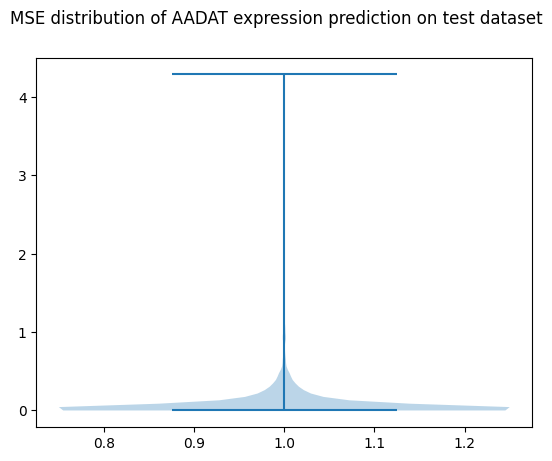

In [ ]:
MSE_distrubution = test_loss_distribution(test_dataloader, model, loss_fn, optimiser)

# Saving model

In [ ]:
torch.save(model, 'models/linear_with_network.pth')

In [ ]:
#How to load for reference
model = torch.load('models/linear_with_network.pth', weights_only=False)